# Assignment2 - Supervised Machine Learning Fundamentals

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


---
## Exercise 1 - Conceptual Questions on Supervised Learning I

**1.1**     
Expect better.          
Because large n can fit the underlying pattern more accuratly without as much risk of overfitting. Also, large n provides enough information to distinguish the singal from the noise, allowing a flexible model to find a closer fit to teh true functional form.

**1.2**     
Expect worse.       
Few data means the flexible model will find the pattern in the random noise, which is overfitting. Inflexible model perform better because their contrains prevent them from chasing every outlier in a small sample.

**1.3**     
Expect better.          
The flexible method makes strong assumptions about the shape of the data. If the true relationship is curvy or complex, and inflexible model will have high bias.

**1.4**     
Expect worse.           
High variance means the data has high noise. A flexible method will follow the noise, mistaking random fluctuations for the actual relationship. Inflexible method is more robust because it effectively averages out the noise to be more simpler.


---
## Exercise 2 - Conceptual Questions on Supervised learning II

**2.1**     
(i) Regression, because the response variable is the salary and salary is the continuous value.     
(ii) Inference, becuae the question wants us to understand which factors affect CEO salary, which means we need to know the relationship between different variable, not just predict the new data.         
(iii) Sample n = 500, predictor p = 3(profit, number of employees, industry)        

**2.2**         
(i) Classification, because the response variable is whether the product is a success or failure, which is discrete             
(ii) Prediction, because the goal is to determine the likely outcome a future product based on existing data.           
(iii) Sample n = 20, predictor p = 13

**2.3**

(i) Regression, because the response variable is % change in the US dollar, which is a continuous numerical value.          
(ii) Prediction, because we're interested in using world market changes to estimate the future movement of dollar.          
(iii) Sample n = 52 (52 weeks per year), predictor p = 3 (% change in US, British, German)

---
## Exercise 3 - Classification using KNN

**3.1**

In [2]:
import numpy as np
import pandas as pd
X = np.array([[ 0, 3, 0],
              [ 2, 0, 0],
              [ 0, 1, 3],
              [ 0, 1, 2],
              [-1, 0, 1],
              [ 1, 1, 1]])
y = np.array(['r','r','r','b','b','r'])

test_point = np.array([0, 0, 0])
distance = np.linalg.norm(X - test_point, axis = 1)
df = pd.DataFrame({'Obs.': np.arange(1, 7),'x1': X[:, 0],'x2': X[:, 1],'x3': X[:, 2],'y': y,'Distance': distance})

print(df.to_string(index = False))

 Obs.  x1  x2  x3 y  Distance
    1   0   3   0 r  3.000000
    2   2   0   0 r  2.000000
    3   0   1   3 r  3.162278
    4   0   1   2 b  2.236068
    5  -1   0   1 b  1.414214
    6   1   1   1 r  1.732051


**3.2**             
Predict when k = 1          
Ans: Blue, when k = 1, the prediction is based on the single observation in the training set that is closest to the test point, which is obs 5 (blue).

**3.3**         
Predict when k = 3      
Ans: Red        
Base on the Euclidean distance, the three observations closest to the test point are obs5, obs6, obs2.      
2 red labels and 1 blue label, so KNN predicts y = red.

**3.4**         
I would expect the best value of k to be small.         
A small k provides a more flexible model with a lower bias, allowing the decision boundary to follow non-linear patterns in the data.       
Also if K increases, the decision boundary becomes more linear because it averages the labels over a larger neighborhood.
Therefore, a highly non-linear Bayes ecision boundary requires the model to capture complex shapes, a small K is necessary to provide the required.

---
## Exercise 4 - Build my own classification algorithm

**4.1**

In [3]:
# Skeleton code for part (a) to write your own kNN classifier

class Knn:
# k-Nearest Neighbor class object for classification training and testing
    def __init__(self):
        self.x_train = None
        self.y_train = None
    def fit(self, x, y):
        # Save the training data to properties of this class
        self.x_train = x 
        self.y_train = y
        
    def predict(self, x, k):
        y_hat = [] # Variable to store the estimated class label for 
        # Calculate the distance from each vector in x to the training data
        for test in x:
            distance = np.sqrt(np.sum((self.x_train - test) ** 2, axis = 1))
            nearest_neighbor = np.argsort(distance)[:k]
            k_nearest_labels = self.y_train[nearest_neighbor]
            unique, counts = np.unique(k_nearest_labels, return_counts=True)
            prediction = unique[np.argmax(counts)]
            y_hat.append(prediction)
        # Return the estimated targets
        return np.array(y_hat)

# Metric of overall classification accuracy
#  (a more general function, sklearn.metrics.accuracy_score, is also available)
def accuracy(y,y_hat):
    nvalues = len(y)
    accuracy = sum(y == y_hat) / nvalues
    return accuracy

**4.2 Load the datasets**

In [4]:
import pandas as pd

x_train_low = pd.read_csv('data/A2_Q4_X_train_low.csv' , header=None).values
y_train_low = pd.read_csv('data/A2_Q4_y_train_low.csv' , header=None).values.flatten()
x_test_low  = pd.read_csv('data/A2_Q4_X_test_low.csv', header=None).values
y_test_low  = pd.read_csv('data/A2_Q4_y_test_low.csv', header=None).values.flatten()
x_train_high = pd.read_csv('data/A2_Q4_X_train_high.csv', header=None).values
y_train_high = pd.read_csv('data/A2_Q4_y_train_high.csv', header=None).values.flatten()
x_test_high  = pd.read_csv('data/A2_Q4_X_test_high.csv', header=None).values
y_test_high  = pd.read_csv('data/A2_Q4_y_test_high.csv', header=None).values.flatten()
print(f"Low-dim train shape: {x_train_low.shape}")   
print(f"High-dim train shape: {x_train_high.shape}") 

Low-dim train shape: (1000, 2)
High-dim train shape: (1000, 100)


**4.3 Model Result**

In [5]:
import time
def evaluate(x_train, y_train, x_test, y_test, k=5, label="Dataset"):
    knn = Knn()
    knn.fit(x_train, y_train)
    start_time = time.time()
    y_hat = knn.predict(x_test, k=k)
    end_time = time.time()
    acc = accuracy(y_test, y_hat)
    duration = end_time - start_time
    
    print(f"--- {label} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Time taken: {duration:.4f} seconds\n")
    return acc, duration

acc_low, time_low = evaluate(x_train_low, y_train_low, x_test_low, y_test_low, k=5, label="Low Dimensional (p=2)")
acc_high, time_high = evaluate(x_train_high, y_train_high, x_test_high, y_test_high, k=5, label="High Dimensional (p=100)")

--- Low Dimensional (p=2) ---
Accuracy: 0.9250
Time taken: 0.1215 seconds

--- High Dimensional (p=100) ---
Accuracy: 0.9930
Time taken: 0.5500 seconds



**4.4 Compare with sklearn result**

In [8]:
from sklearn.neighbors import KNeighborsClassifier
sk_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean', algorithm='brute')
sk_knn.fit(x_train_low, y_train_low)
start = time.time()
sk_y_hat = sk_knn.predict(x_test_low)
sk_time = time.time() - start
print("--- Low Dimensional ---")
print(f"Sklearn Accuracy: {accuracy(y_test_low, sk_y_hat):.4f}")
print(f"Sklearn Time: {sk_time:.4f}s")

sk_knn.fit(x_train_high, y_train_high)
start = time.time()
sk_y_hat = sk_knn.predict(x_test_high)
sk_time = time.time() - start
print("\n--- High Dimensional ---")
print(f"Sklearn Accuracy: {accuracy(y_test_high, sk_y_hat):.4f}")
print(f"Sklearn Time: {sk_time:.4f}s")

--- Low Dimensional ---
Sklearn Accuracy: 0.9250
Sklearn Time: 0.0390s

--- High Dimensional ---
Sklearn Accuracy: 0.9930
Sklearn Time: 0.0380s


The SKlearn accuracy for the low and high dimensional is exactly the same as my own model's result.     
But the performance has gap, the sklearn time is much faster than mine.

**4.5**   
**Drawback:**       
      
If the prediction process is slow, the model cannot provide immediate feedback, which is critical for the systems that requiring real-time interaction. Also it requires more CPU/GPU resources for every single new data point. Additionally, if we need to process millions of predictions, slow inference can create a massive lag that stalls the entire system.        

**Some Cases:**          
1. Like high frequency trading, in the stock market, algorithms make trades in microseconds. If the inference process is slower than competitior's, the opportunity for the profit may lost.       
2. Self-driving car must classify many situation in microseconds. While trainging the model can take a lot of time on supercomputer, a slow inference speed in this field could lead to accidents.
   



---
## Exercise 5 - Bias-variance tradeoff: exploring the tradeoff with a KNN classifer


**5.1 Create a synthetic data** 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from matplotlib.colors import LinearSegmentedColormap

X, y = make_moons(n_samples=1000, noise=0.35, random_state=42)
colors = [(255/255, 150/255, 150/255), (150/255, 180/255, 255/255)]
newcmp = LinearSegmentedColormap.from_list("new", colors, N=2)

**5.2 Visiualize data**

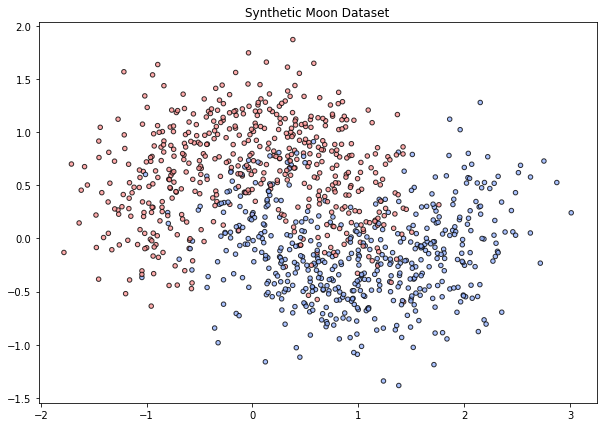

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=newcmp, edgecolor='k', s=20, alpha=0.8)
plt.title("Synthetic Moon Dataset")
plt.show()

**5.3**

In [15]:
models = []
dataset = []

np.random.seed(42)

# Repeat 3 times to generate 3 different dataset
for i in range(3):
    indices = np.random.choice(range(len(x)), size = 100, replace=True)
    x_subset = X[indices]
    y_subset = y[indices]
    dataset.append((x_subset, y_subset))

    subset_models = {}
    for k in [1, 25, 50]:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(x_subset, y_subset)
        subset_models[k] = knn

    models.append(subset_models)
print(f"Successfully trained {len(models) * 3} combinations")

Successfully trained 9 combinations


**5.4**

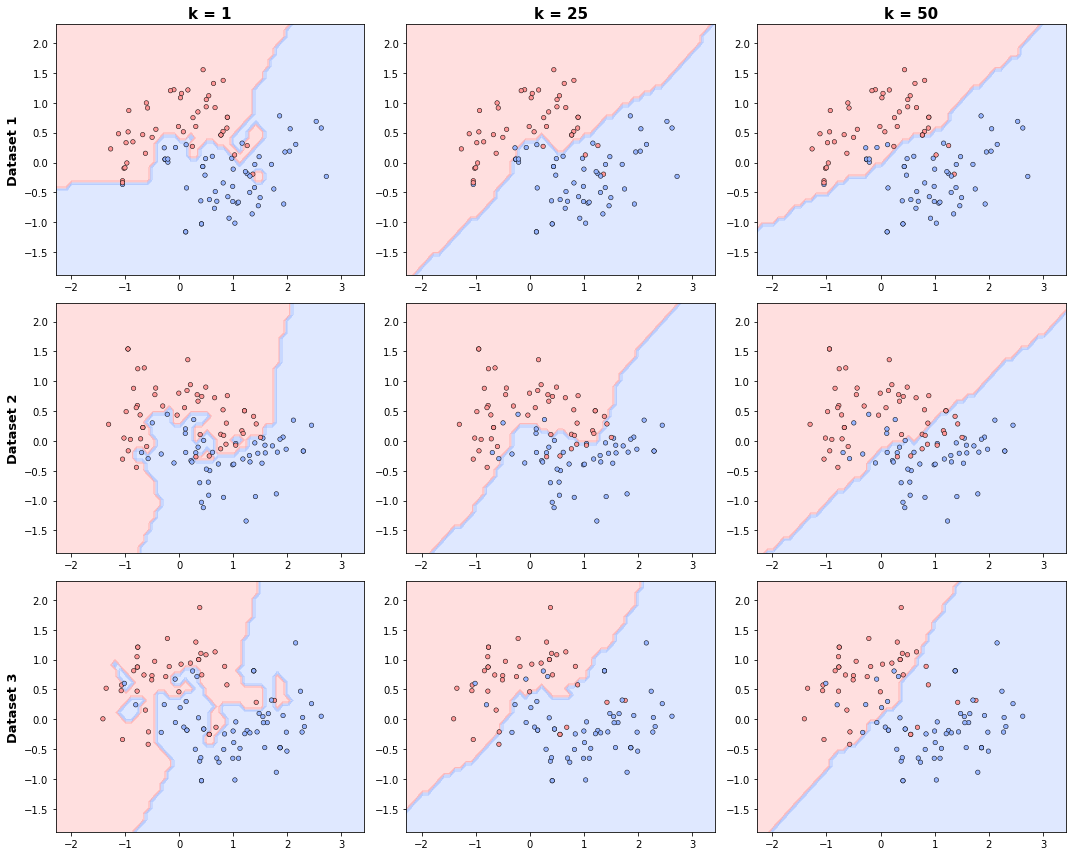

In [16]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

fig, axes = plt.subplots(3, 3, figsize = (15, 12))
ks = [1, 25, 50]

for row in range(3):
    x_sub, y_sub = dataset[row]
    for col, k in enumerate(ks):
        
        # Take the knn model from the models dic
        ax = axes[row, col]
        knn_model = models[row][k]

        # Predict classification of the node
        Z = knn_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Draw the decision area
        ax.contourf(xx, yy, Z, alpha=0.3, cmap=newcmp)

        # Draw the original node
        ax.scatter(x_sub[:, 0], x_sub[:, 1], c=y_sub, cmap=newcmp, edgecolor='k', s=20, linewidth=0.5)

        if row == 0:
            ax.set_title(f"k = {k}", fontsize=15, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f"Dataset {row+1}", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**5.5**     

1. Differences in Rows and Columns  

    **Columms:** As it move from left to right, the decision boundaries become significantly smoother and simpler. At k = 1, the boundary is jagged and follows every individual point. Nevertheless, if k = 50, the boundary is nearly a straight line, ignoring local clusters.          

    **Row:** As it move down the row, it can looking at how the model reacts todifferent random samples of the same distrubution. When k = 1 column, the boundaries look completely different in each row. Neverless, when k = 50, the boundaries look almost identical across all three rows.

2. Best Separation of Training Data

    The k = 1 decisioin boundaries appear to best separate the 2 classes with respect to the trainging data. Because the classifier creates a area around every single trainging point. It captures every outlier and noise spike in the specific 100 point subset.

3. Most Variation with Training Data    

    The k = 1 decision boundaries vary the most as the dataset. Because the model is so flexible, it's very sensitive to the specific points in the sample. 

4. Best Generalization to Unseen Data

    The k = 25 is the best generalization. Because k = 1 is overfitting, its too fiexible the noise of the datas, which won't exist in the same places in new data.              
    The k = 50 is unferfitting, because it's too rigid. It has smoothed the boundary so much that it's starting to ignore the actual moon curvature.



**5.6**

1. High Variance (k = 1)        
    Because k = 1, the boundary is forced to stick around every single outlier in the subset, this leads to low bias but high variance. This is overfitting, the model just memorized the noise rather than learning the singal

2. High Bias (k = 50)       
    By looking at the 50 nearest neighbors, the local noise is averaged out, resulting in a nearly linear boundary that stays the same across all three rows. This leads to low variace but high bias. This is underfitting, it's too simple to capture the underlying pattern.

3. Balanced model (k = 25)
    The boundary is smooth enough to ignore random noise but flexible enough to follow the actual curve. It keep both bias and variance at a level where the total error is minized.

The goal of supervised learning is to find the point on the total error(bias + variance) at its minimum. We cannot just choose the model with the lowest training error(k = 1) as that usually indicates high variance. As data increases, models can typically handle more flexibility without the variance.




---
## Exercise 6 - Bias-variance trade-off II: Quantifying the trade off

**6.1 Generate Test Data**      

In [17]:
x_test, y_test = make_moons(n_samples= 1000, noise = 0.35, random_state=123)
x_train, y_train = X, y

**6.2 Train a KNN classifier**

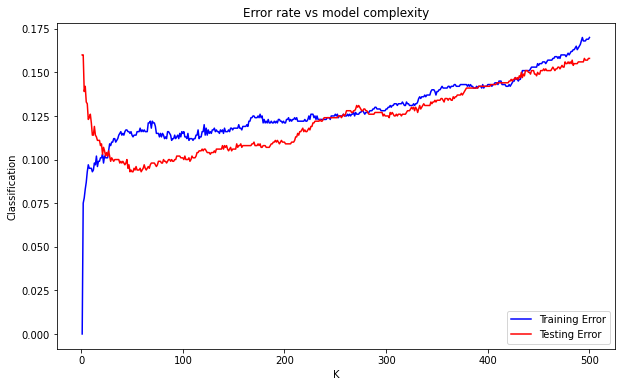

In [22]:
train_errors = []
test_errors = []
k_values = range(1, 501)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    train_errors.append(1 - knn.score(x_train, y_train))
    test_errors.append(1 - knn.score(x_test, y_test))

plt.figure(figsize= (10, 6))
plt.plot(k_values, train_errors, label = 'Training Error', color = 'blue')
plt.plot(k_values, test_errors, label = 'Testing Error', color = 'red')
plt.xlabel('K')
plt.ylabel('Classification')
plt.title('Error rate vs model complexity')
plt.legend()
plt.show()

**6.3 What trend do you see in the results**            

1. Training Error: Starts at exactly 0 when k = 1, and stedaily increases as k grown. Because as t he model becomes less flexible, it can no longer memorize every specific of generalization error         

2. Testing Error: It starts high in the begining, then decreases to a minimum point, and starts to increase again as k approach 500, creating the U shape


**6.4 What values of k represent high bias and which represent high variance**              

1. High Variance: Represented by the small k. In the result, the training error is very low, but the testing error is pretty high, indicating the model is overfitting to the noise in the training set.

2. High bias: Represented by the large k. Both training and testing errors are high becuae the model is too simple to caputure the moon pattern.



**6.5 What is the optimal value of k and why**

The optimal value is around between k = 30 to 60, where the red line reaches its lowest point. This period represents the best balance in the bias-variance trade off. Its flexible enough to learn the underlying structure of the data but rigid enough to ignore the random noise.

**6.6 What controls the flexibiliby of other models**

1. Decision Tree: controlled by the maximum depth of the tree or the samples per leaf       
2. Regression: controlled by lamda or alpha
3. Polyminal Regression: controlled by the degree of the polynomial

---
## Exercise 7 - Linear regression and nonlinear tranformations


**7.1 Create a scatter plot**

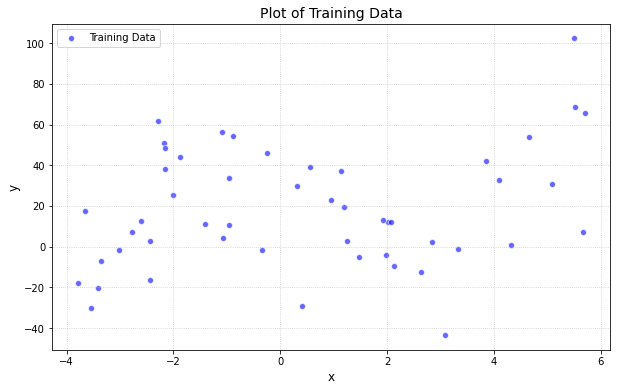

In [29]:
import pandas as pd
path = './data/' 
train = pd.read_csv(path + 'A2_Q7_train.csv')
test = pd.read_csv(path + 'A2_Q7_test.csv')

x_train = train.x.values
y_train = train.y.values
x_test = test.x.values
y_test = test.y.values

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='blue', alpha=0.6, edgecolors='white', label='Training Data')
plt.title('Plot of Training Data', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

**4.2**

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model_baseline = LinearRegression()
model_baseline.fit(x_train.reshape(-1, 1), y_train)

# 2. Get predictions for the training data
y_pred_train = model_baseline.predict(x_train.reshape(-1, 1))

# 3. Calculate metrics
r2 = r2_score(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)

# 4. Extract coefficients for the equation
a0 = model_baseline.intercept_
a1 = model_baseline.coef_[0]

print(f"R^2 Value: {r2:.4f}")
print(f"Mean Square Error: {mse:.4f}")
print(f"Estimated Model Equation: y = {a0:.4f} + {a1:.4f}x")

R^2 Value: 0.0649
Mean Square Error: 791.4167
Estimated Model Equation: y = 17.2049 + 2.5907x


**7.4**

In [31]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly_train = poly.fit_transform(x_train.reshape(-1, 1))

model_poly = LinearRegression()
model_poly.fit(X_poly_train, y_train)
y_poly_pred = model_poly.predict(X_poly_train)
r2_poly = r2_score(y_train, y_poly_pred)
mse_poly = mean_squared_error(y_train, y_poly_pred)

intercept = model_poly.intercept_
coeffs = model_poly.coef_

print(f"New R^2 Value: {r2_poly:.4f}")
print(f"New Mean Square Error: {mse_poly:.4f}")
print(f"Estimated Equation: y = {intercept:.2f} + ({coeffs[0]:.2f})x + ({coeffs[1]:.2f})x^2 + ({coeffs[2]:.2f})x^3")

New R^2 Value: 0.3963
New Mean Square Error: 510.8850
Estimated Equation: y = 24.16 + (-9.25)x + (-2.13)x^2 + (0.90)x^3


**7.4**

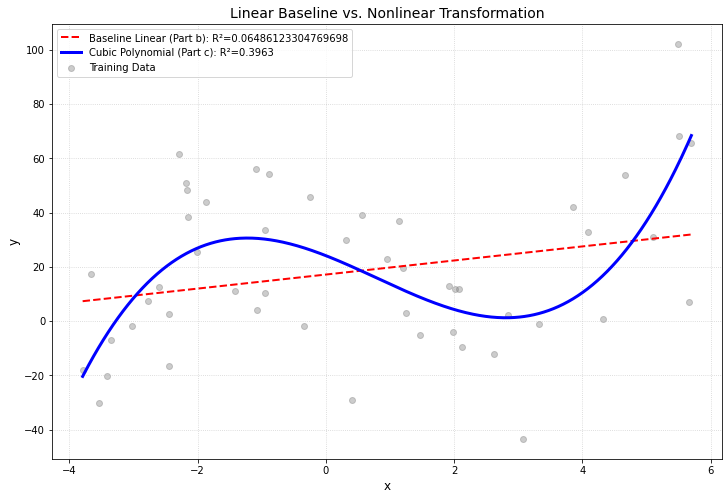

In [35]:
import matplotlib.pyplot as plt

x_range = np.linspace(x_train.min(), x_train.max(), 500).reshape(-1, 1)

y_baseline_plot = model_baseline.predict(x_range)
x_range_poly = poly.transform(x_range)
y_poly_plot = model_poly.predict(x_range_poly)
plt.figure(figsize=(12, 8))

plt.scatter(x_train, y_train, color='gray', alpha=0.4, label='Training Data')

#part b
plt.plot(x_range, y_baseline_plot, color='red', linestyle='--', linewidth=2, label=f'Baseline Linear (Part b): R²={r2}')

#part c
plt.plot(x_range, y_poly_plot, color='blue', linewidth=3, label=f'Cubic Polynomial (Part c): R²={0.3963:.4f}')

# Formatting
plt.title('Linear Baseline vs. Nonlinear Transformation', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

**7.5**

In [36]:

x_test_reshaped = x_test.reshape(-1, 1)
y_pred_base_test = model_baseline.predict(x_test_reshaped)
r2_base_test = r2_score(y_test, y_pred_base_test)
mse_base_test = mean_squared_error(y_test, y_pred_base_test)

x_test_poly = poly.transform(x_test_reshaped)
y_pred_poly_test = model_poly.predict(x_test_poly)

r2_poly_test = r2_score(y_test, y_pred_poly_test)
mse_poly_test = mean_squared_error(y_test, y_pred_poly_test)

print("--- Baseline Model (Linear) Test Results ---")
print(f"Test R^2: {r2_base_test:.4f}")
print(f"Test MSE: {mse_base_test:.4f}")

print("\n--- Polynomial Model (Cubic) Test Results ---")
print(f"Test R^2: {r2_poly_test:.4f}")
print(f"Test MSE: {mse_poly_test:.4f}")

--- Baseline Model (Linear) Test Results ---
Test R^2: -0.1329
Test MSE: 1116.6632

--- Polynomial Model (Cubic) Test Results ---
Test R^2: 0.2295
Test MSE: 759.5031


**7.6**

Performance Comparison:         
1.  In training data, the polynomial model performed significantly better. It's $R^2$ is 0.3963 compared to the baseline models's 0.0649            
2.  In testing data, the polynomial model also performed better. It's $R^2$ is 0.2295 compared to the baseline models's -0.1329.        

This is beause the scatter plot in 7.1 revealed a nonlinear relationship that a straight line could not follow. And by transforming x into $x^2$ and $x^3$, the polynomial model gained the flexibility needed to curve and match the data's actual shape.